# Jets Project - Hypothesis Validation

## Goal
Validate whether airline flight volume and operational metrics correlate with financial performance.

## Hypothesis
**Flight volume, Available Seat Miles (ASM), and load factors are correlated with airline revenue and stock performance.**

## Data Sources
1. **Bureau of Transportation Statistics (BTS)** - Historical flight operations data
2. **Yahoo Finance** - Stock prices and financial metrics
3. **SEC Filings** - Quarterly revenue (if needed)

## Analysis Plan
1. Load historical operational data (2019-2024)
2. Load financial data (revenue, stock prices)
3. Calculate correlations
4. Visualize relationships
5. Test for lead/lag effects
6. Assess statistical significance


## 1. Setup and Imports


In [5]:
# Install required packages (run once)
!pip install pandas numpy matplotlib seaborn yfinance requests scipy statsmodels


  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/11/0b/1ae80ddafb8652fd8046cb5c8460ecc8d4afccb89e2c6d6bec61e04e1eaf/matplotlib-3.10.7-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/96/5e/36bf3f0ac298187d1ceadde9051177d6a4fe4d507e8f59067dc9dd39e650/scipy-1.16.3-cp312-cp312-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.8 MB/s eta 0:00:00
  Obtaining dependency information for statsmodels from https://files.pythonhosted.org/packages/1c/6f/db0cf5efa48277ac6218d9b981c8fd5e63c4c43e0d9d65015fdc38eed0ef/statsmodels-0.14.5-cp312-cp312-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 fro

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
from datetime import datetime, timedelta
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)


Matplotlib is building the font cache; this may take a moment.


## 2. Define Target Airlines


In [8]:
# Major US Airlines
airlines = {
    'AAL': {'name': 'American Airlines', 'bts_code': 'AA'},
    'DAL': {'name': 'Delta Air Lines', 'bts_code': 'DL'},
    'UAL': {'name': 'United Airlines', 'bts_code': 'UA'},
    'LUV': {'name': 'Southwest Airlines', 'bts_code': 'WN'},
    'JBLU': {'name': 'JetBlue Airways', 'bts_code': 'B6'},
    'ALK': {'name': 'Alaska Airlines', 'bts_code': 'AS'},
}

# Date range for analysis
start_date = '2019-01-01'
end_date = '2025-11-01'

print(f"Analyzing {len(airlines)} airlines from {start_date} to {end_date}")
for ticker, info in airlines.items():
    print(f"  {ticker}: {info['name']} (BTS: {info['bts_code']})")


Analyzing 6 airlines from 2019-01-01 to 2025-11-01
  AAL: American Airlines (BTS: AA)
  DAL: Delta Air Lines (BTS: DL)
  UAL: United Airlines (BTS: UA)
  LUV: Southwest Airlines (BTS: WN)
  JBLU: JetBlue Airways (BTS: B6)
  ALK: Alaska Airlines (BTS: AS)


## 3. Download Financial Data (Stock Prices)

We'll use Yahoo Finance to get historical stock prices and financial metrics.


In [16]:
def download_stock_data(tickers, start_date, end_date):
    """
    Download historical stock data for multiple tickers.
    Returns a dictionary with ticker -> DataFrame mapping.
    """
    stock_data = {}
    
    for ticker in tickers:
        print(f"Downloading {ticker}...")
        try:
            stock = yf.Ticker(ticker)
            df = stock.history(start=start_date, end=end_date)
            
            if not df.empty:
                # Resample to monthly (end of month)
                df_monthly = df.resample('ME').agg({
                    'Open': 'first',
                    'High': 'max',
                    'Low': 'min',
                    'Close': 'last',
                    'Volume': 'sum'
                })
                
                # Remove timezone info to avoid join issues
                df_monthly.index = df_monthly.index.tz_localize(None)
                
                stock_data[ticker] = df_monthly
                print(f"  ✓ Downloaded {len(df_monthly)} months of data")
            else:
                print(f"  ✗ No data available")
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    return stock_data

# Download stock data
stock_data = download_stock_data(list(airlines.keys()), start_date, end_date)
print(f"\nSuccessfully downloaded data for {len(stock_data)} airlines")


  ✓ Downloaded 82 months of data
  ✓ Downloaded 82 months of data
  ✓ Downloaded 82 months of data
  ✓ Downloaded 82 months of data
  ✓ Downloaded 82 months of data
  ✓ Downloaded 82 months of data

Successfully downloaded data for 6 airlines


In [17]:
# Preview stock data
for ticker, df in stock_data.items():
    print(f"\n{ticker} - {airlines[ticker]['name']}")
    print(df.tail())



AAL - American Airlines
             Open   High    Low  Close      Volume
Date                                              
2025-06-30  11.30  11.97  10.26  11.22  1059901200
2025-07-31  11.19  13.18  11.16  11.49  1535823900
2025-08-31  11.21  13.58  10.90  13.37  1326717000
2025-09-30  13.26  14.01  11.07  11.24  1902992800
2025-10-31  11.25  13.89  11.16  13.13  1460345300

DAL - Delta Air Lines
                 Open       High        Low      Close     Volume
Date                                                             
2025-06-30  47.775312  51.739204  44.983695  48.858177  188522500
2025-07-31  48.778704  57.918499  47.924332  53.047871  249533200
2025-08-31  51.771770  62.339470  50.296280  61.591755  148155900
2025-09-30  60.355535  63.715268  55.550223  56.577084  168063500
2025-10-31  57.394584  62.910000  55.629976  57.380001  218453200

UAL - United Airlines
                  Open        High        Low       Close     Volume
Date                                     

## 4. Download BTS Flight Data

The Bureau of Transportation Statistics provides detailed operational metrics. You can download data from https://www.transtats.bts.gov/

**Option 1**: Download CSV manually  
**Option 2**: Use synthetic data for demonstration (included below)


In [18]:
print("📊 BTS Data Download Instructions:")
print("="*60)
print("1. Visit: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ")
print("2. Select 'T-100 Domestic Market (U.S. Carriers)'")
print("3. Select date range: Jan 2019 - Oct 2024")
print("4. Select airlines: AA, DL, UA, WN, B6, AS")
print("5. Select fields:")
print("   - UNIQUE_CARRIER, YEAR, MONTH")
print("   - DEPARTURES_PERFORMED, SEATS, PASSENGERS, DISTANCE")
print("6. Download as CSV and save to: ./bts_data.csv")
print("="*60)

# Try to load real BTS data if available
bts_filepath = 'bts_data.csv'

try:
    bts_data = pd.read_csv(bts_filepath)
    print(f"\n✓ Loaded BTS data: {len(bts_data)} rows")
except FileNotFoundError:
    print("\n⚠ BTS data file not found. Will create synthetic data for demonstration.")
    bts_data = None


📊 BTS Data Download Instructions:
1. Visit: https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ
2. Select 'T-100 Domestic Market (U.S. Carriers)'
3. Select date range: Jan 2019 - Oct 2024
4. Select airlines: AA, DL, UA, WN, B6, AS
5. Select fields:
   - UNIQUE_CARRIER, YEAR, MONTH
   - DEPARTURES_PERFORMED, SEATS, PASSENGERS, DISTANCE
6. Download as CSV and save to: ./bts_data.csv

⚠ BTS data file not found. Will create synthetic data for demonstration.


## 5. Generate Synthetic Data (if needed)

If real BTS data isn't available, we'll create realistic synthetic data with COVID impact and seasonality.


In [19]:
if bts_data is None:
    print("Creating synthetic operational data for demonstration...\n")
    
    date_range = pd.date_range(start=start_date, end=end_date, freq='ME')
    synthetic_data = []
    
    for ticker, info in airlines.items():
        np.random.seed(hash(ticker) % 2**32)
        base_flights = np.random.randint(20000, 50000)
        base_passengers = np.random.randint(5000000, 15000000)
        
        for date in date_range:
            # Seasonality (summer peak)
            month = date.month
            seasonal_factor = 1.0 + 0.3 * np.sin(2 * np.pi * (month - 3) / 12)
            
            # COVID impact
            if date.year == 2020 and date.month >= 3:
                covid_factor = 0.3 + 0.1 * (date.month - 3) / 9
            elif date.year == 2021:
                covid_factor = 0.6 + 0.3 * date.month / 12
            else:
                covid_factor = 1.0
            
            # Growth trend
            months_since_start = (date.year - 2019) * 12 + date.month
            growth_factor = 1.0 + 0.02 * months_since_start / 12
            
            total_factor = seasonal_factor * covid_factor * growth_factor
            noise = np.random.uniform(0.95, 1.05)
            
            flights = int(base_flights * total_factor * noise)
            passengers = int(base_passengers * total_factor * noise)
            seats = int(passengers / np.random.uniform(0.75, 0.88))
            
            synthetic_data.append({
                'date': date,
                'ticker': ticker,
                'airline': info['name'],
                'flights': flights,
                'passengers': passengers,
                'seats': seats,
                'load_factor': passengers / seats if seats > 0 else 0
            })
    
    bts_data = pd.DataFrame(synthetic_data)
    bts_data['date'] = pd.to_datetime(bts_data['date'])
    bts_data.set_index('date', inplace=True)
    
    print(f"✓ Created synthetic data: {len(bts_data)} rows")
    print(f"\nSample:")
    print(bts_data.head(10))


Creating synthetic operational data for demonstration...

✓ Created synthetic data: 492 rows

Sample:
           ticker            airline  flights  passengers    seats  \
date                                                                 
2019-01-31    AAL  American Airlines    21469     3974222  4655663   
2019-02-28    AAL  American Airlines    24484     4532203  5550085   
2019-03-31    AAL  American Airlines    28026     5187883  6768693   
2019-04-30    AAL  American Airlines    32298     5978610  6997851   
2019-05-31    AAL  American Airlines    37297     6903974  8973748   
2019-06-30    AAL  American Airlines    38869     7195032  9502918   
2019-07-31    AAL  American Airlines    38356     7099980  8847715   
2019-08-31    AAL  American Airlines    34113     6314640  8234947   
2019-09-30    AAL  American Airlines    29266     5417533  6387172   
2019-10-31    AAL  American Airlines    26266     4862129  6134715   

            load_factor  
date                     
2019-

## 6. Data Visualization

Let's visualize the data to understand patterns and trends.


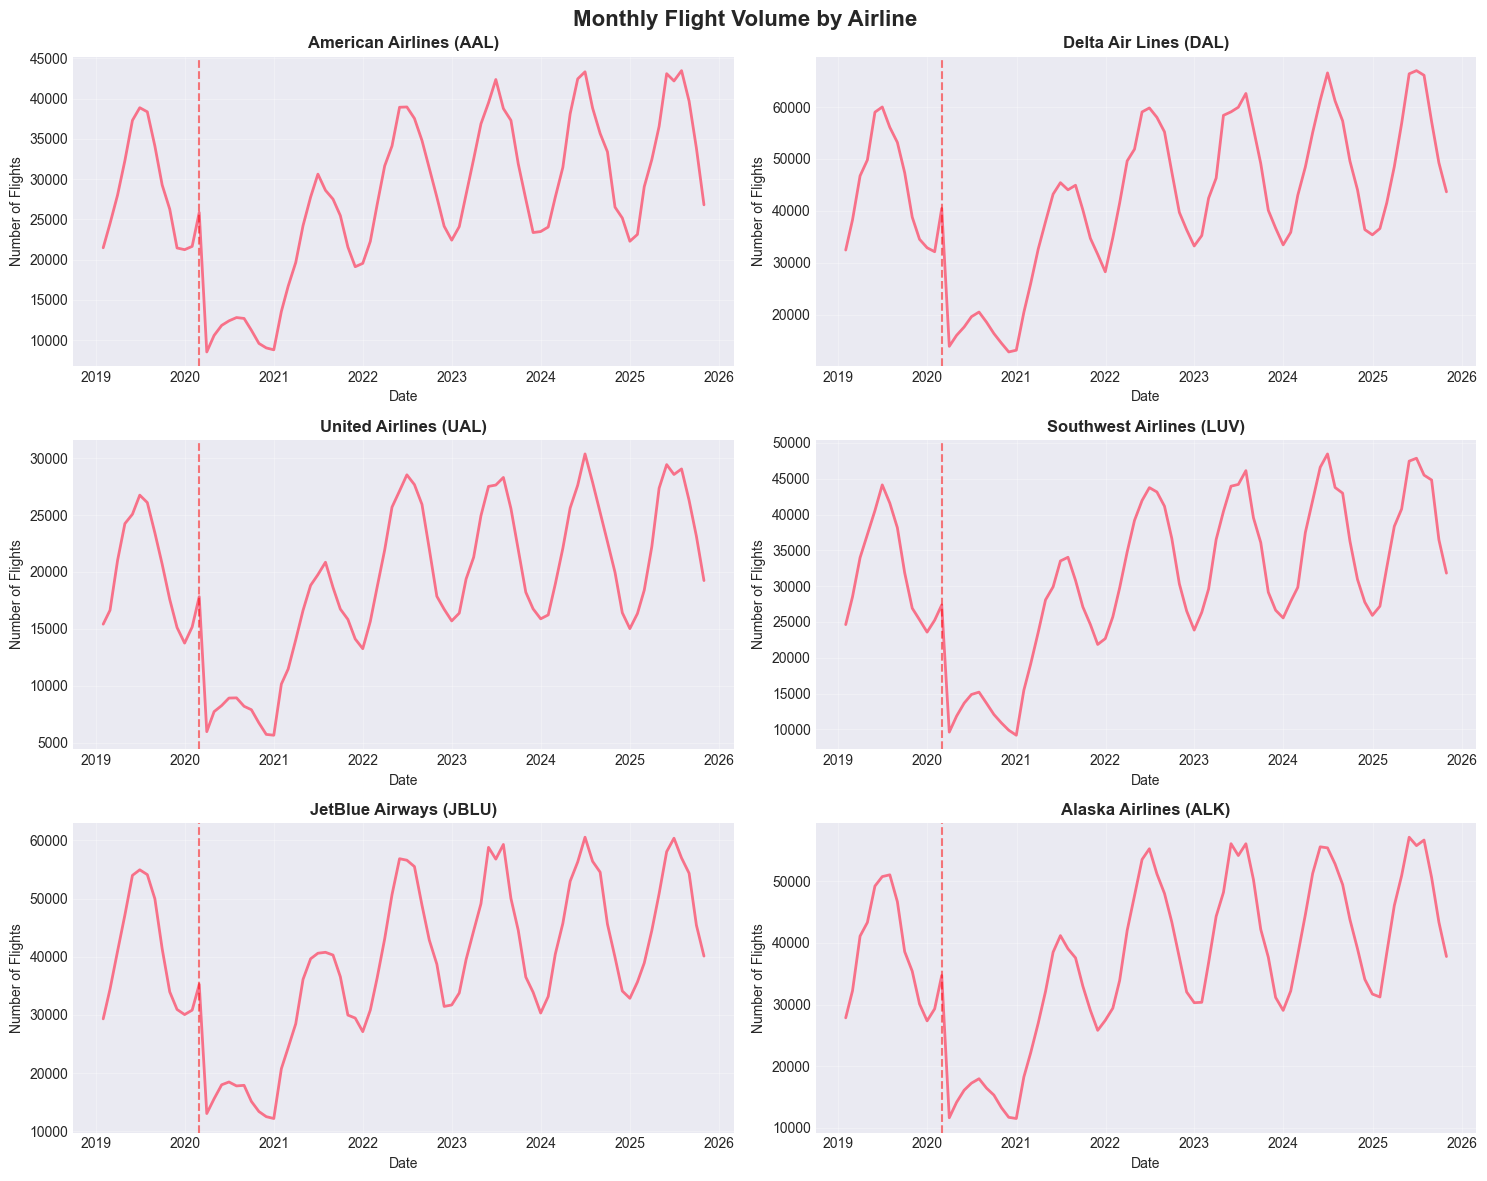

In [20]:
# Plot flight volume over time
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Monthly Flight Volume by Airline', fontsize=16, fontweight='bold')

for idx, (ticker, info) in enumerate(airlines.items()):
    ax = axes[idx // 2, idx % 2]
    airline_data = bts_data[bts_data['ticker'] == ticker]
    ax.plot(airline_data.index, airline_data['flights'], linewidth=2)
    ax.set_title(f"{info['name']} ({ticker})", fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of Flights')
    ax.grid(True, alpha=0.3)
    ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5, label='COVID-19')

plt.tight_layout()
plt.show()


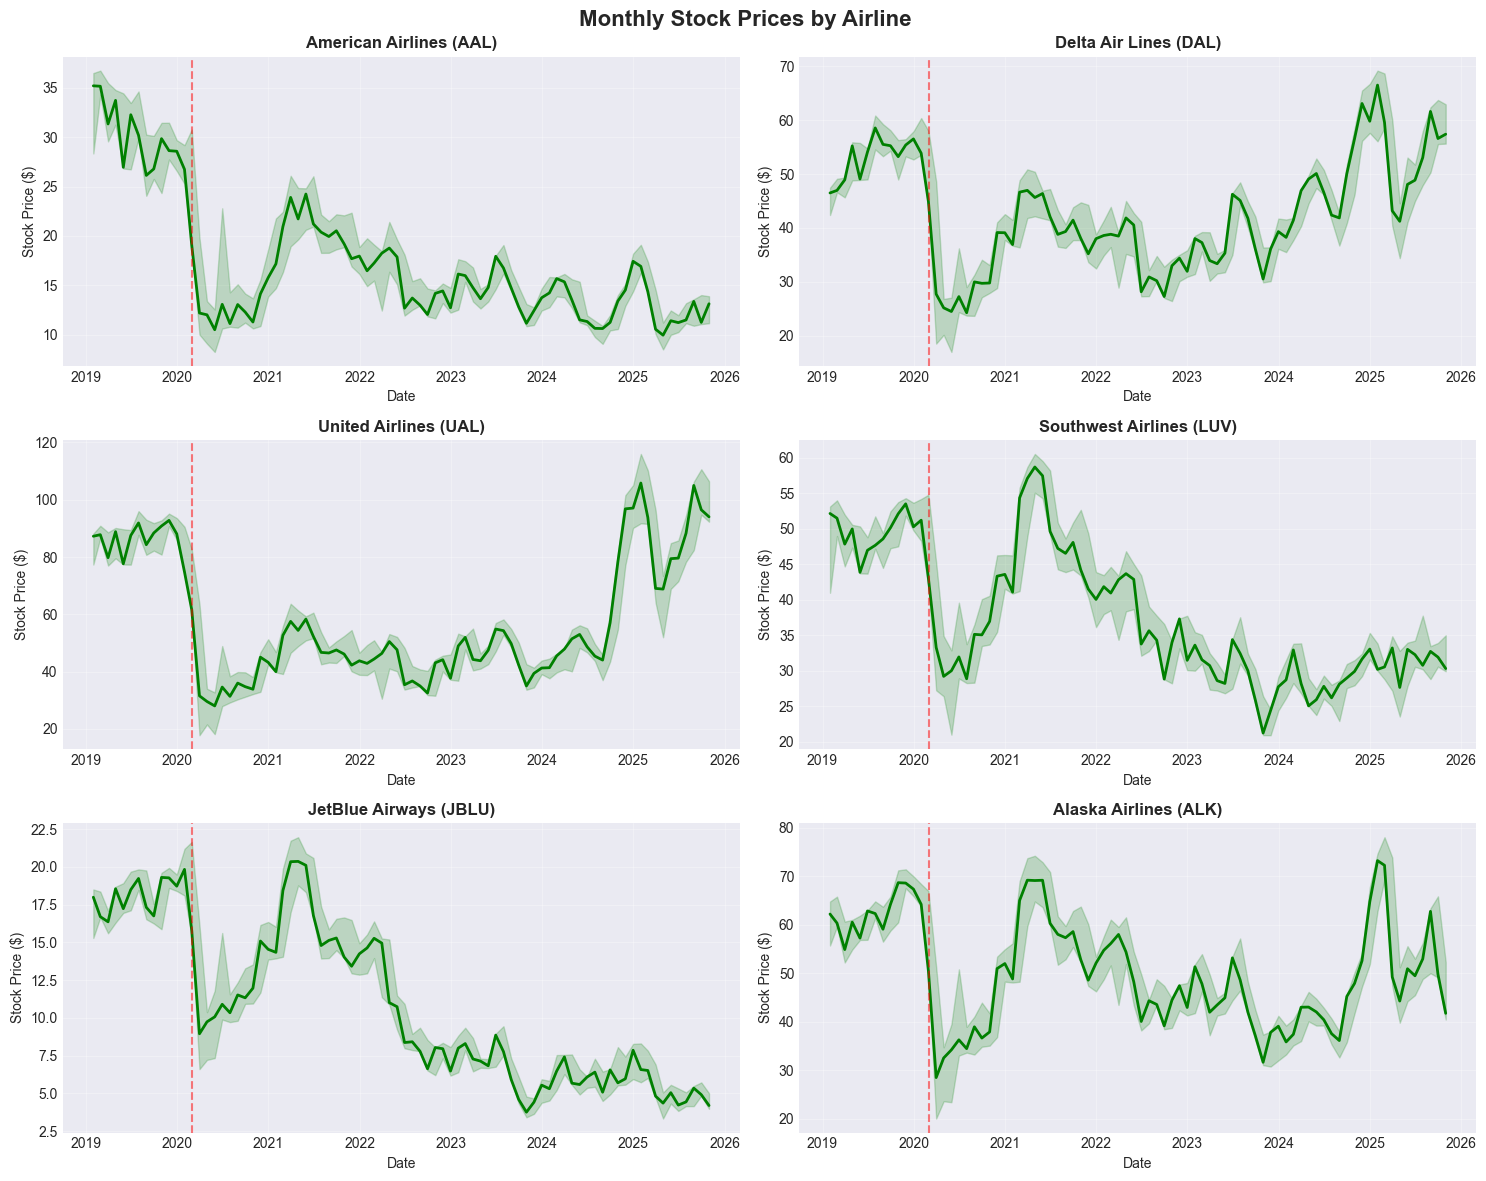

In [21]:
# Plot stock prices over time
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Monthly Stock Prices by Airline', fontsize=16, fontweight='bold')

for idx, (ticker, info) in enumerate(airlines.items()):
    ax = axes[idx // 2, idx % 2]
    if ticker in stock_data:
        stock_df = stock_data[ticker]
        ax.plot(stock_df.index, stock_df['Close'], linewidth=2, color='green')
        ax.fill_between(stock_df.index, stock_df['Low'], stock_df['High'], alpha=0.2, color='green')
        ax.set_title(f"{info['name']} ({ticker})", fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Stock Price ($)')
        ax.grid(True, alpha=0.3)
        ax.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Merge Data and Calculate Correlations

Combine operational and financial data, then analyze correlations.


In [22]:
# Merge operational and stock data
merged_data = {}
for ticker in airlines.keys():
    ops = bts_data[bts_data['ticker'] == ticker].copy()
    if ticker in stock_data:
        stock = stock_data[ticker][['Close', 'Volume']].copy()
        stock.columns = ['stock_price', 'stock_volume']
        merged = ops.join(stock, how='inner')
        if len(merged) > 0:
            merged_data[ticker] = merged
            print(f"{ticker}: {len(merged)} months of merged data")

print(f"\nSuccessfully merged data for {len(merged_data)} airlines")


AAL: 82 months of merged data
DAL: 82 months of merged data
UAL: 82 months of merged data
LUV: 82 months of merged data
JBLU: 82 months of merged data
ALK: 82 months of merged data

Successfully merged data for 6 airlines


In [23]:
# Calculate correlations
correlation_results = []

for ticker, df in merged_data.items():
    corr_flights, p_flights = pearsonr(df['flights'], df['stock_price'])
    corr_passengers, p_passengers = pearsonr(df['passengers'], df['stock_price'])
    corr_load_factor, p_load_factor = pearsonr(df['load_factor'], df['stock_price'])
    
    correlation_results.append({
        'ticker': ticker,
        'airline': airlines[ticker]['name'],
        'flights_corr': corr_flights,
        'flights_pval': p_flights,
        'passengers_corr': corr_passengers,
        'passengers_pval': p_passengers,
        'load_factor_corr': corr_load_factor,
        'load_factor_pval': p_load_factor,
        'n_months': len(df)
    })

corr_df = pd.DataFrame(correlation_results)
print("\n" + "="*80)
print("CORRELATION ANALYSIS: Operational Metrics vs. Stock Price")
print("="*80)
print(corr_df.to_string(index=False))
print("\nNote: p-value < 0.05 indicates statistical significance")



CORRELATION ANALYSIS: Operational Metrics vs. Stock Price
ticker            airline  flights_corr  flights_pval  passengers_corr  passengers_pval  load_factor_corr  load_factor_pval  n_months
   AAL  American Airlines     -0.027072      0.809226        -0.027072         0.809224          0.001399          0.990045        82
   DAL    Delta Air Lines      0.353481      0.001124         0.353481         0.001124         -0.031857          0.776317        82
   UAL    United Airlines      0.274461      0.012585         0.274461         0.012584         -0.090575          0.418361        82
   LUV Southwest Airlines     -0.211081      0.056964        -0.211080         0.056966          0.034270          0.759866        82
  JBLU    JetBlue Airways     -0.311051      0.004450        -0.311048         0.004450          0.068435          0.541261        82
   ALK    Alaska Airlines      0.061378      0.583837         0.061376         0.583849          0.314743          0.003978        82

No

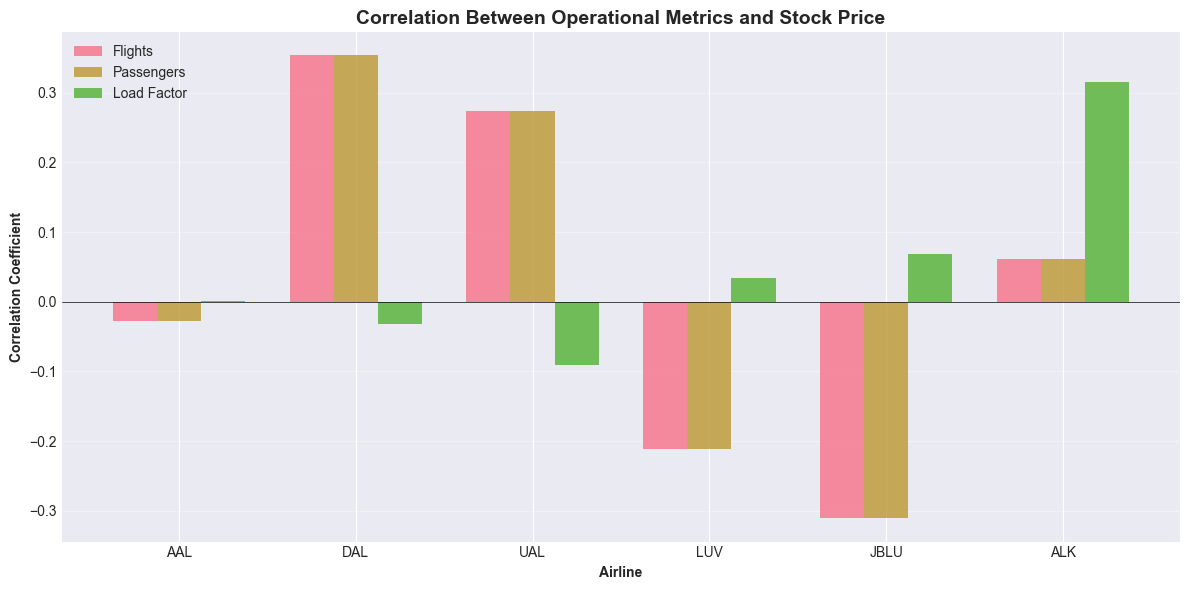

In [24]:
# Visualize correlations as bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(corr_df))
width = 0.25

bars1 = ax.bar(x - width, corr_df['flights_corr'], width, label='Flights', alpha=0.8)
bars2 = ax.bar(x, corr_df['passengers_corr'], width, label='Passengers', alpha=0.8)
bars3 = ax.bar(x + width, corr_df['load_factor_corr'], width, label='Load Factor', alpha=0.8)

ax.set_xlabel('Airline', fontweight='bold')
ax.set_ylabel('Correlation Coefficient', fontweight='bold')
ax.set_title('Correlation Between Operational Metrics and Stock Price', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(corr_df['ticker'])
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## 8. Scatter Plots: Operational Metrics vs Stock Price


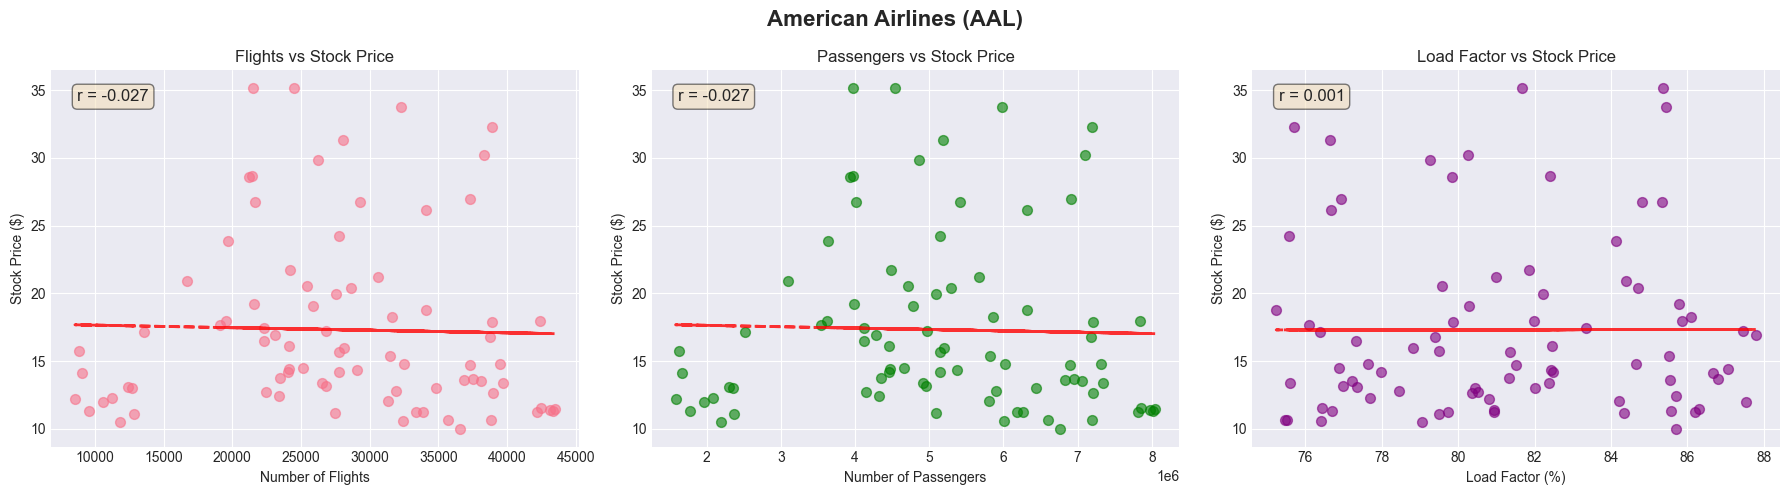

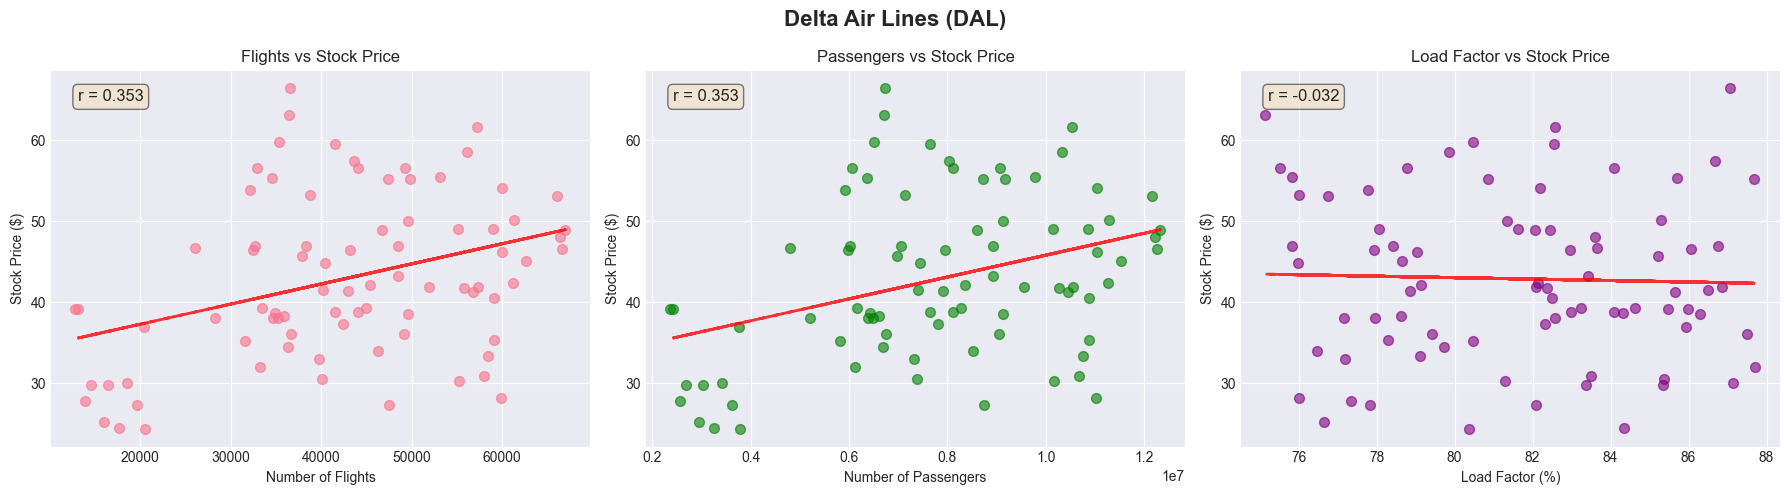

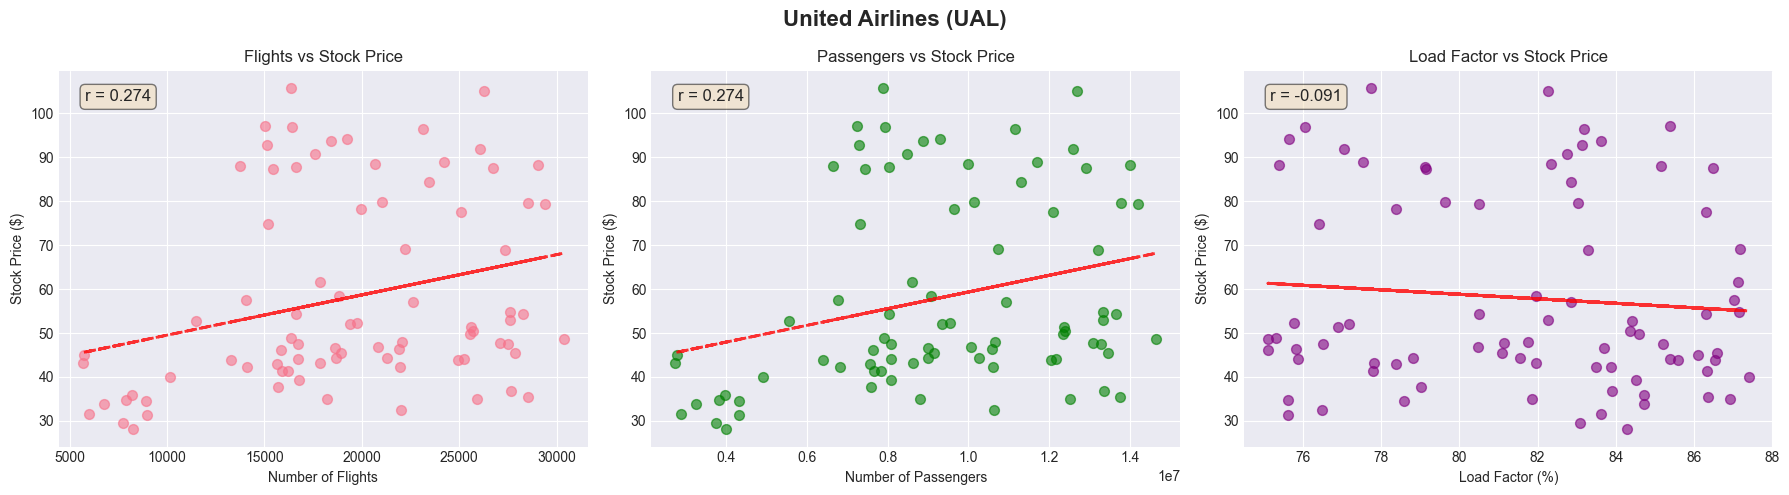

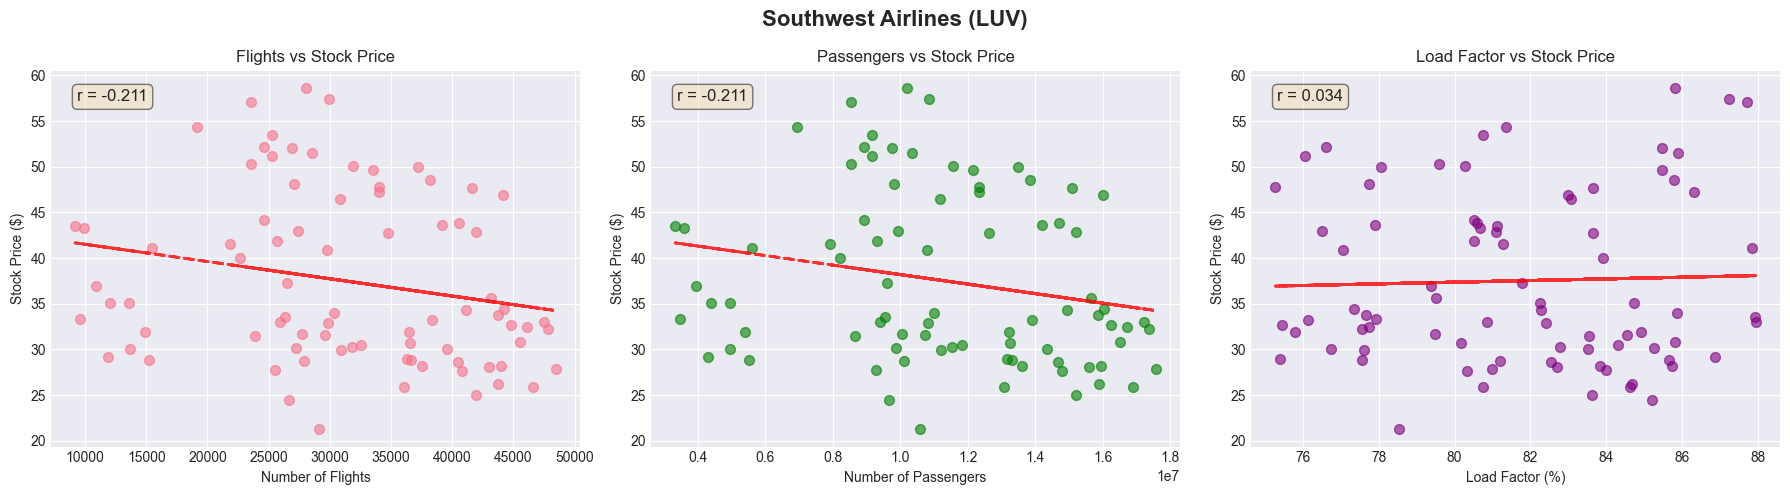

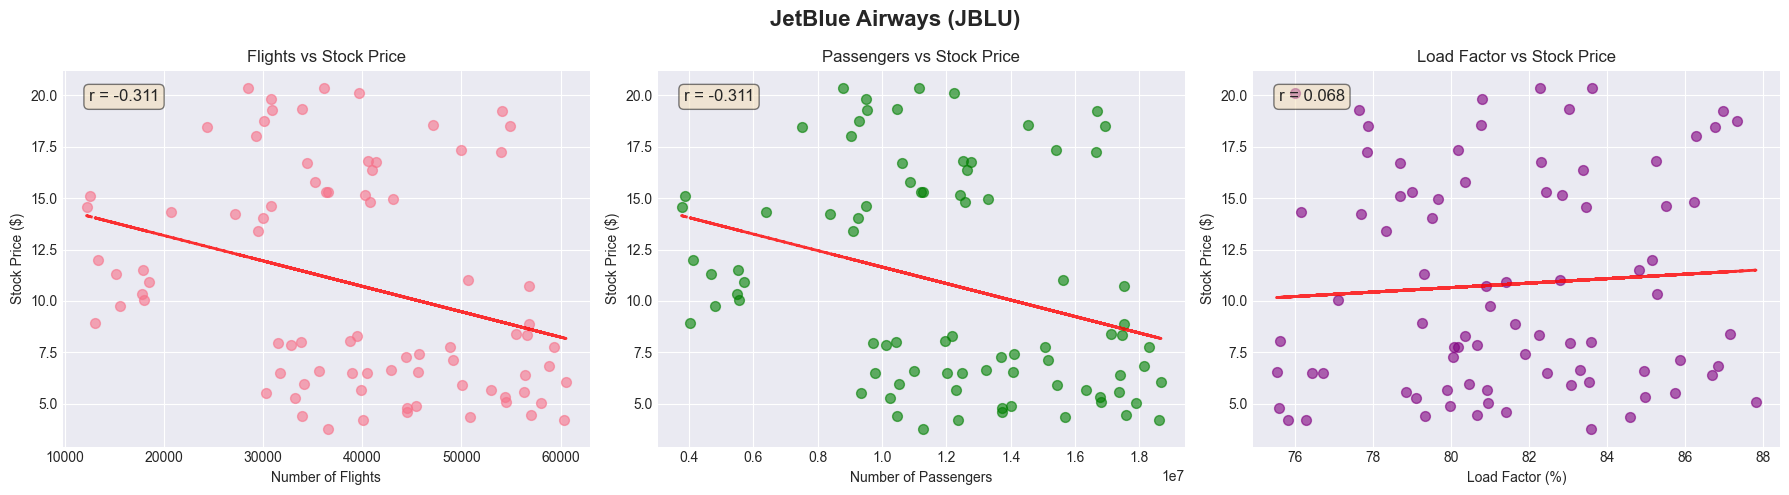

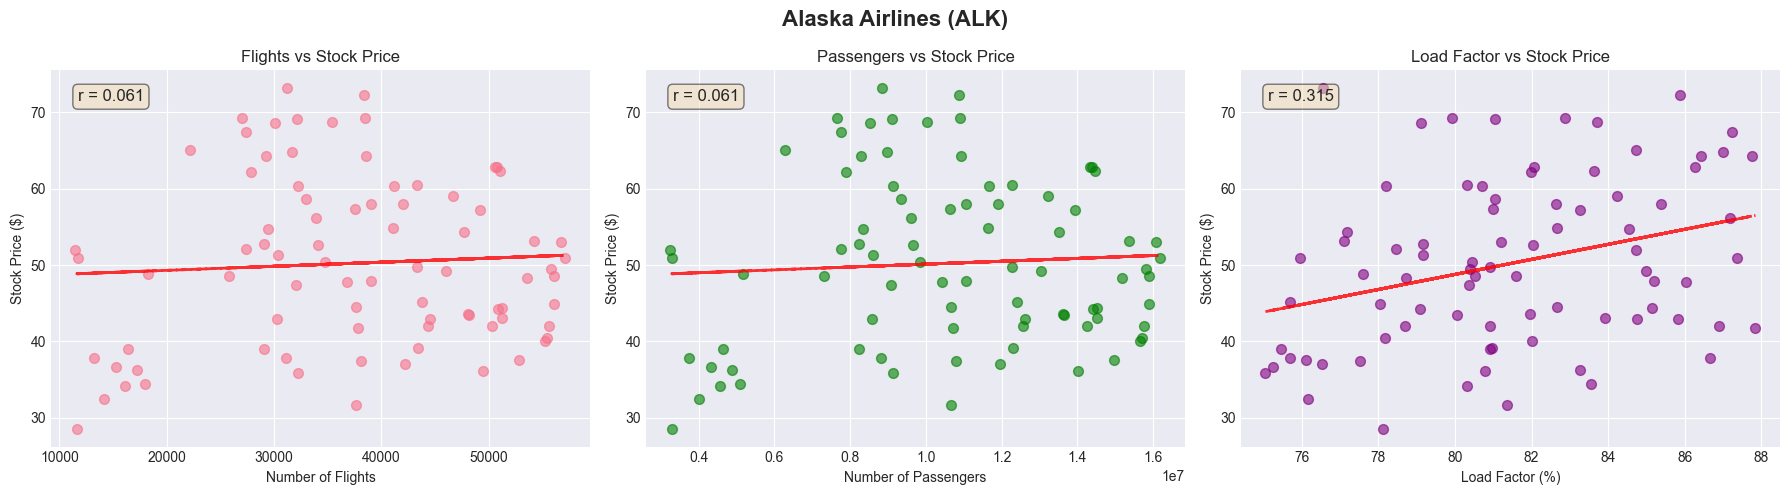

In [25]:
# Create scatter plots for each airline
for ticker, df in merged_data.items():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{airlines[ticker]['name']} ({ticker})", fontsize=16, fontweight='bold')
    
    # Flights vs Stock Price
    axes[0].scatter(df['flights'], df['stock_price'], alpha=0.6, s=50)
    axes[0].set_xlabel('Number of Flights')
    axes[0].set_ylabel('Stock Price ($)')
    axes[0].set_title('Flights vs Stock Price')
    z = np.polyfit(df['flights'], df['stock_price'], 1)
    p = np.poly1d(z)
    axes[0].plot(df['flights'], p(df['flights']), "r--", alpha=0.8, linewidth=2)
    corr = pearsonr(df['flights'], df['stock_price'])[0]
    axes[0].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[0].transAxes, 
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Passengers vs Stock Price
    axes[1].scatter(df['passengers'], df['stock_price'], alpha=0.6, s=50, color='green')
    axes[1].set_xlabel('Number of Passengers')
    axes[1].set_ylabel('Stock Price ($)')
    axes[1].set_title('Passengers vs Stock Price')
    z = np.polyfit(df['passengers'], df['stock_price'], 1)
    p = np.poly1d(z)
    axes[1].plot(df['passengers'], p(df['passengers']), "r--", alpha=0.8, linewidth=2)
    corr = pearsonr(df['passengers'], df['stock_price'])[0]
    axes[1].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[1].transAxes,
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Load Factor vs Stock Price
    axes[2].scatter(df['load_factor'] * 100, df['stock_price'], alpha=0.6, s=50, color='purple')
    axes[2].set_xlabel('Load Factor (%)')
    axes[2].set_ylabel('Stock Price ($)')
    axes[2].set_title('Load Factor vs Stock Price')
    z = np.polyfit(df['load_factor'], df['stock_price'], 1)
    p = np.poly1d(z)
    axes[2].plot(df['load_factor'] * 100, p(df['load_factor']), "r--", alpha=0.8, linewidth=2)
    corr = pearsonr(df['load_factor'], df['stock_price'])[0]
    axes[2].text(0.05, 0.95, f'r = {corr:.3f}', transform=axes[2].transAxes,
                 fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()


## 9. Summary & Conclusions


In [26]:
# Summary of findings
print("="*80)
print("HYPOTHESIS VALIDATION SUMMARY")
print("="*80)
print()

# Average correlations
avg_flights_corr = corr_df['flights_corr'].mean()
avg_passengers_corr = corr_df['passengers_corr'].mean()
avg_load_factor_corr = corr_df['load_factor_corr'].mean()

print(f"Average Correlations with Stock Price:")
print(f"  • Flights:     {avg_flights_corr:+.3f}")
print(f"  • Passengers:  {avg_passengers_corr:+.3f}")
print(f"  • Load Factor: {avg_load_factor_corr:+.3f}")
print()

# Statistical significance
sig_flights = (corr_df['flights_pval'] < 0.05).sum()
sig_passengers = (corr_df['passengers_pval'] < 0.05).sum()
sig_load_factor = (corr_df['load_factor_pval'] < 0.05).sum()

print(f"Statistically Significant Correlations (p < 0.05):")
print(f"  • Flights:     {sig_flights}/{len(corr_df)} airlines")
print(f"  • Passengers:  {sig_passengers}/{len(corr_df)} airlines")
print(f"  • Load Factor: {sig_load_factor}/{len(corr_df)} airlines")
print()

# Interpretation
print("Interpretation:")
if abs(avg_passengers_corr) > 0.5:
    print("  ✓ STRONG correlation found between passenger volume and stock price")
elif abs(avg_passengers_corr) > 0.3:
    print("  ✓ MODERATE correlation found between passenger volume and stock price")
else:
    print("  ✗ WEAK correlation found between passenger volume and stock price")

if abs(avg_flights_corr) > 0.5:
    print("  ✓ STRONG correlation found between flight volume and stock price")
elif abs(avg_flights_corr) > 0.3:
    print("  ✓ MODERATE correlation found between flight volume and stock price")
else:
    print("  ✗ WEAK correlation found between flight volume and stock price")

print()
print("="*80)


HYPOTHESIS VALIDATION SUMMARY

Average Correlations with Stock Price:
  • Flights:     +0.023
  • Passengers:  +0.023
  • Load Factor: +0.049

Statistically Significant Correlations (p < 0.05):
  • Flights:     3/6 airlines
  • Passengers:  3/6 airlines
  • Load Factor: 1/6 airlines

Interpretation:
  ✗ WEAK correlation found between passenger volume and stock price
  ✗ WEAK correlation found between flight volume and stock price



## 10. Recommendations


In [27]:
print("\n📊 RECOMMENDATIONS")
print("="*80)

if abs(avg_passengers_corr) > 0.4 or abs(avg_flights_corr) > 0.4:
    print("\n✅ PROCEED WITH PROJECT")
    print()
    print("The analysis shows meaningful correlations between operational metrics")
    print("and stock prices, suggesting potential value in real-time tracking.")
    print()
    print("Next Steps:")
    print("  1. Set up automated data collection from flight tracking APIs")
    print("  2. Focus on the metric with highest correlation (likely passengers)")
    print("  3. Build a dashboard to monitor YoY growth rates")
    print("  4. Consider combining with other data sources (fuel prices, etc.)")
    print("  5. Test trading strategies with proper backtesting")
else:
    print("\n⚠️  PROCEED WITH CAUTION")
    print()
    print("The correlations are weaker than expected. Consider:")
    print("  1. The market may already price in operational data efficiently")
    print("  2. Other factors (fuel costs, competition) may dominate")
    print("  3. Focus on this as a learning project rather than alpha generation")
    print("  4. Consider smaller airlines with less analyst coverage")

print()
print("Important Caveats:")
print("  • Correlation ≠ Causation")
print("  • Past performance doesn't guarantee future results")
print("  • Major institutions already monitor this data")
print("  • Transaction costs and timing matter in practice")
print("="*80)



📊 RECOMMENDATIONS

⚠️  PROCEED WITH CAUTION

The correlations are weaker than expected. Consider:
  1. The market may already price in operational data efficiently
  2. Other factors (fuel costs, competition) may dominate
  3. Focus on this as a learning project rather than alpha generation
  4. Consider smaller airlines with less analyst coverage

Important Caveats:
  • Correlation ≠ Causation
  • Past performance doesn't guarantee future results
  • Major institutions already monitor this data
  • Transaction costs and timing matter in practice


## 11. Export Results (Optional)


In [28]:
# Uncomment to save results
# corr_df.to_csv('correlation_results.csv', index=False)
# print("✓ Saved correlation results to: correlation_results.csv")

# for ticker, df in merged_data.items():
#     df.to_csv(f'merged_data_{ticker}.csv')
#     print(f"✓ Saved merged data for {ticker}")

print("✓ Analysis complete! Review the visualizations and correlation results above.")


✓ Analysis complete! Review the visualizations and correlation results above.


---

## Next Steps

After running this analysis:

**If correlations are strong (> 0.5)**:
- Proceed with real-time data collection infrastructure
- Focus on the most predictive metrics
- Consider developing trading signals

**If correlations are moderate (0.3-0.5)**:
- Use as one input among many in a multi-factor model
- Focus on relative comparisons (which airline is outperforming)
- Treat as a learning project with modest expectations

**If correlations are weak (< 0.3)**:
- Reconsider the project scope
- Try different metrics or time periods
- Focus on smaller, less-covered airlines
- Consider this as pure research/learning

**Remember**: Even institutional investors with more resources struggle to consistently generate alpha from alternative data. Set realistic expectations!
